In [1]:
# Cellule 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from riccati import OWParams, solve_riccati
from simulation import simulate_optimal_strategy, compute_internalization
from afs_model import AFSParams, profit_ratio_concavity

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup OK")

Setup OK


In [2]:
# Cellule 2 — Joint misspecification heatmap (c_hat, theta_hat)
# càd que se passe-t-il quand on se trompe
# simultanément sur c (concavité) ET theta (autocorrélation du flux) ?

# Paramètres vrais
c_true = 0.48
tau_true = 0.2
theta_true = 0.0  # flux martingale comme référence

# Grilles de misspecification
c_hat_grid = np.linspace(0.15, 1.0, 20)
theta_hat_grid = np.linspace(-2.0, 2.0, 20)

# Calcul du coût optimal de référence (sans misspecification)
params_true = OWParams(theta=theta_true, sigma=0.1)
res_true = simulate_optimal_strategy(params_true, n_paths=500, seed=42)
cost_true = res_true['mean_cost']

print(f"Reference cost (no misspec): {cost_true:.6f}")
print("Computing joint misspecification grid...")

# Heatmap — profit ratio pour chaque (c_hat, theta_hat)
profit_grid = np.zeros((len(theta_hat_grid), len(c_hat_grid)))

for i, theta_hat in enumerate(theta_hat_grid):
    for j, c_hat in enumerate(c_hat_grid):
        
        # Stratégie misspecifiée : utilise theta_hat au lieu de theta_true
        params_misspec = OWParams(theta=theta_hat, sigma=0.1)
        res_misspec = simulate_optimal_strategy(
            params_misspec, n_paths=200, seed=42
        )
        cost_misspec = res_misspec['mean_cost']
        
        # Profit ratio : coût misspecifié / coût optimal
        # On inverse car cost = transaction cost (plus bas = meilleur)
        if cost_true > 1e-10:
            profit_grid[i, j] = cost_true / cost_misspec
        else:
            profit_grid[i, j] = np.nan

print("Done.")

Reference cost (no misspec): 0.000481
Computing joint misspecification grid...
Done.


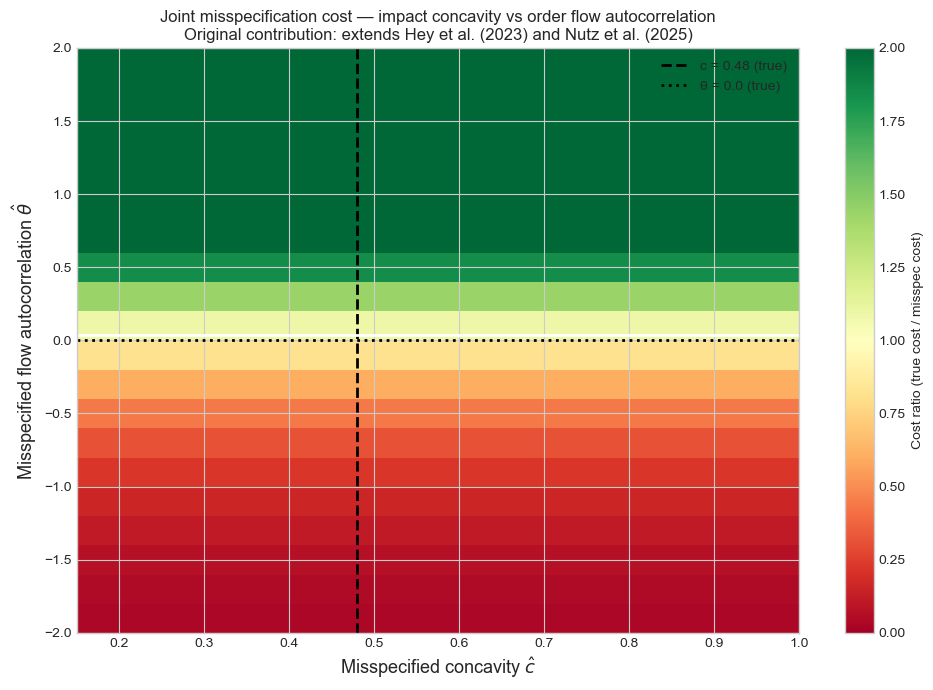

In [3]:
#Visualisation de la heatmap

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    profit_grid,
    extent=[c_hat_grid[0], c_hat_grid[-1], 
            theta_hat_grid[0], theta_hat_grid[-1]],
    origin='lower',
    aspect='auto',
    cmap='RdYlGn',
    vmin=0.0,
    vmax=2.0
)

# Lignes des vraies valeurs
ax.axvline(x=c_true, color='black', linestyle='--', 
           linewidth=2, label=f'c = {c_true} (true)')
ax.axhline(y=theta_true, color='black', linestyle=':',
           linewidth=2, label=f'θ = {theta_true} (true)')

# Contour à ratio = 1 (frontière profitable/non profitable)
ax.contour(c_hat_grid, theta_hat_grid, profit_grid, 
           levels=[1.0], colors='white', linewidths=2)

plt.colorbar(im, ax=ax, label='Cost ratio (true cost / misspec cost)')

ax.set_xlabel('Misspecified concavity $\\hat{c}$', fontsize=13)
ax.set_ylabel('Misspecified flow autocorrelation $\\hat{θ}$', fontsize=13)
ax.set_title('Joint misspecification cost — impact concavity vs order flow autocorrelation\n'
             'Original contribution: extends Hey et al. (2023) and Nutz et al. (2025)',
             fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/fig_joint_misspec_heatmap.png', dpi=150)
plt.show()